In [369]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.special import jn_zeros

In [370]:
geometry = "square"

In [371]:
x = np.loadtxt(f"../results/{geometry}_x.csv")
y = np.loadtxt(f"../results/{geometry}_y.csv")

eigval_real = np.loadtxt(f"../results/{geometry}_eigval_real.csv")
eigval_imag = np.loadtxt(f"../results/{geometry}_eigval_imag.csv")
eigvec_real = np.loadtxt(f"../results/{geometry}_eigvec_real.csv", delimiter=",")
eigvec_imag = np.loadtxt(f"../results/{geometry}_eigvec_imag.csv", delimiter=",")

eigval = eigval_real + 1j*eigval_imag

if np.all(eigval_imag == 0):
    eigval = np.real(eigval)
    print("All eigenvalues real!")

eigvec = eigvec_real + 1j*eigvec_imag
amplitude = np.abs(eigvec)**2
print(eigvec.shape)


(242, 180)


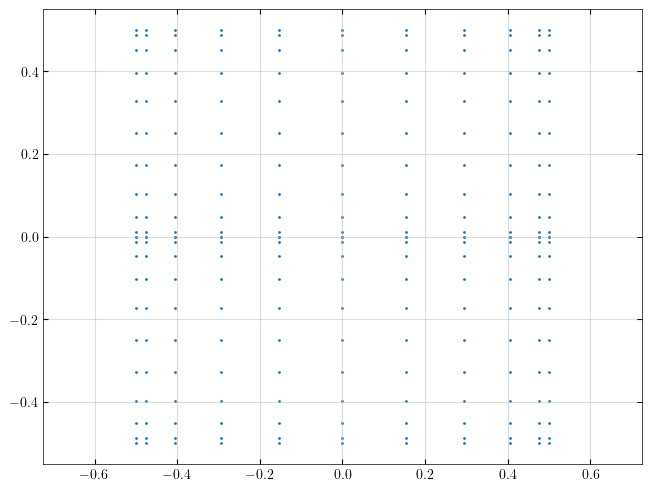

In [372]:
plt.scatter(x, y, s=1)
plt.axis('equal')
plt.show()

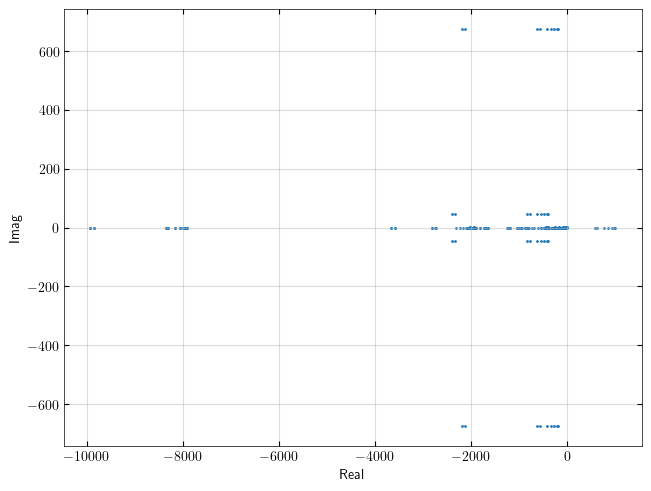

In [373]:
plt.figure()
plt.scatter(eigval_real, eigval_imag, s=1)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.show()

In [374]:
eigval_abs = np.abs(eigval)
idx = np.argsort(eigval_abs)
eigval_abs_sort = eigval_abs[idx]
eigvec_sort = eigvec[:, idx]
amplitude_sort = amplitude[:, idx]

In [375]:
if geometry == "square":
    L_x = max(x) - min(x)
    L_y = max(y) - min(y)
    exact = np.pi**2 * np.sort(np.array([(i/L_x)**2 + (j/L_y)**2 
                  for i in range(1, 100) for j in range(1, 100)]))
elif geometry == "semicircle":
    exact = np.sort(np.ravel([jn_zeros(n, 100)**2 for n in range(1, 100)]))
elif geometry == "circle":
    exact = np.sort(np.ravel([jn_zeros(n, 100)**2 for n in range(0, 100) for polarization in ["x", "y"]]))

exact = exact[:len(eigval_abs_sort)]

rel_error = (eigval_abs_sort - exact) / exact

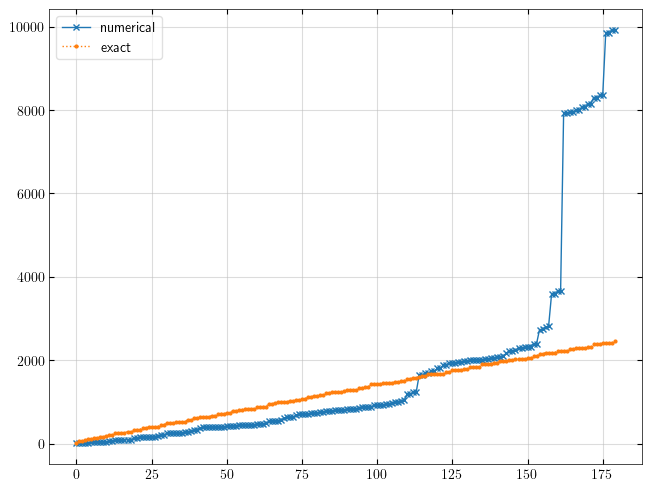

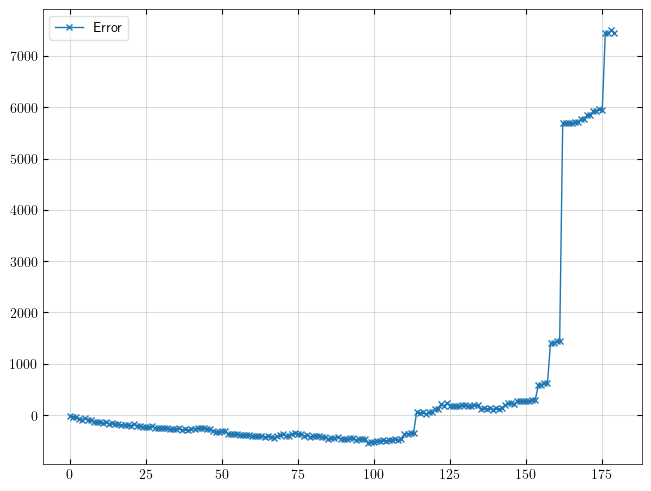

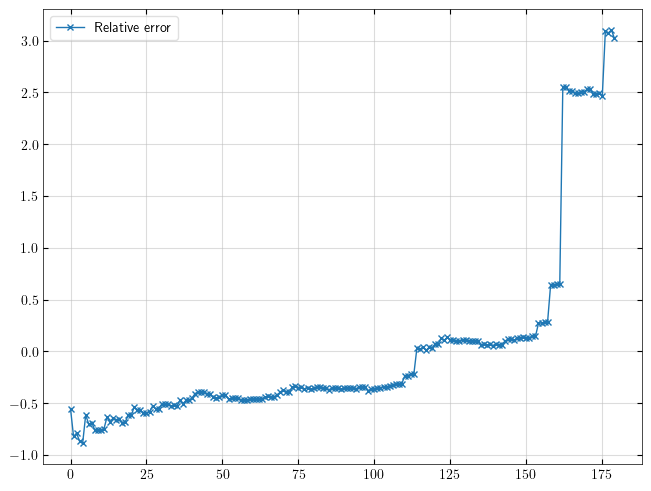

In [376]:
xlim = 200 #len(eigval_abs)//3
plt.figure()
plt.plot(eigval_abs_sort[:xlim], marker='x', markersize=5, linewidth=1, label = "numerical")
plt.plot(exact[:xlim], marker = 'o', markersize = 2, linewidth=1, linestyle = ":", label = "exact")
plt.legend()

plt.figure()
plt.plot(eigval_abs_sort[:xlim] - exact[:xlim], marker='x', markersize=5, linewidth=1, label = 'Error')
plt.legend()

plt.figure()
plt.plot(rel_error[:xlim], marker='x', markersize=5, linewidth=1, label = 'Relative error')
plt.legend()

plt.show()

In [377]:
def plot_interpolated(x, y, z):
    
    xi = np.linspace(min(x), max(x), 500)
    yi = np.linspace(min(y), max(y), 500)
    X_grid, Y_grid = np.meshgrid(xi, yi)
    
    Z = griddata(
        (x, y),
        z,
        (X_grid, Y_grid),
        method='cubic'
    )
    
    plt.contourf(X_grid, Y_grid, Z, levels=20)
    plt.colorbar(label='Amplitude')
    plt.scatter(x, y, c='k', alpha = 0.5, s=1) # Show actual data points
    

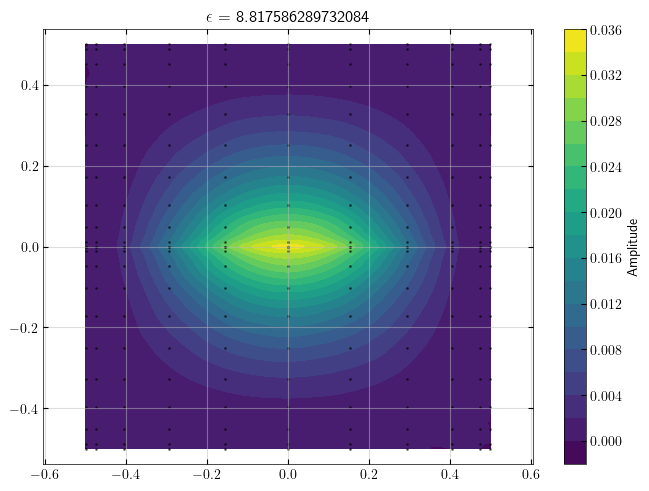

In [378]:
i = 0
psi2 = amplitude_sort[:,i]

plot_interpolated(x, y, psi2)
plt.title(rf"$\epsilon$ = {eigval_abs_sort[i]}")
plt.axis('equal')
plt.show()